# Acoustic Scan 

In [1]:
# matching pursuit
# depth profiling
# attenuation with high f. reflection ok, transmission no
# look at acoustic resonances, dip in attenuation
# 

In [ ]:
%load_ext autoreload
%autoreload 2
import numpy as np
from matplotlib import pyplot as plt
import sys

sys.path.append('..') # path to the src directory
sys.path.append('/Users/xz498/Desktop/ultrasound/data_analysis/ultrasonicTesting/')
sys.path.append('/Users/xz498/Desktop/ultrasound/data_analysis/M3Learning-Util/src/')
sys.path.append('/Users/xz498/Desktop/ultrasound/data_analysis/AutoPhysLearn/src/')
sys.path.append('/Users/xz498/Desktop/ultrasound/data_analysis/ultrasonic_ml/src/')

from scipy.signal import butter, sosfiltfilt
import copy
import math
import time
from tqdm import tqdm

import tomography as tm
import pickleJar as pj

In [3]:
from viz.visualize_scan_data import *
from IPython.display import display
import plotly.graph_objects as go

# Model 1: morlet fit in time domain

## Dataloader with preprocessing

In [22]:
from data import datasets
from data.datasets import morlet_1D_real_dataset

dset = morlet_1D_real_dataset(sq3lite_path='/Users/xz498/Desktop/ultrasound/data_analysis/example_data/SA_tomography_test_metal_plate.sqlite3',
                              dset_name='voltage_echo_forward',
                              image_shape = (1,1),
                            #   crops = [(0,4000)] #(15000,19000)
                            ) 

sqliteToPickle Warning: pickle file /Users/xz498/Desktop/ultrasound/data_analysis/example_data/SA_tomography_test_metal_plate.pickle already exists. Conversion aborted.
preprocessing data...


  0%|          | 0/1 [00:00<?, ?it/s]/Users/xz498/Desktop/ultrasound/data_analysis/ultrasonicTesting/pickleJar.py:1185: RuntimeWarning: divide by zero encountered in log10
  logData = np.log10(abs(data))
100%|██████████| 1/1 [00:00<00:00, 433.52it/s]


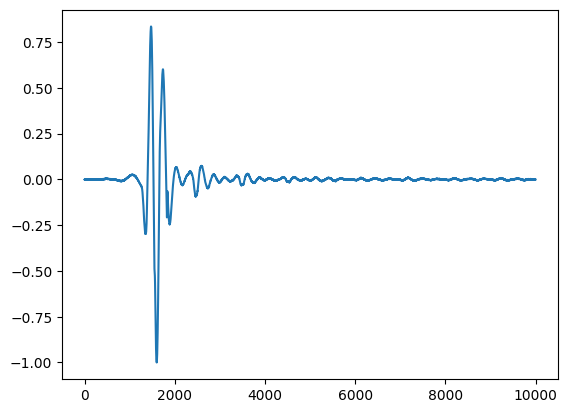

In [25]:
print(dset.shape)
plt.plot(dset[0][1])

## try training model on water with morlet packet

goals:
- figure out mean position and f of morlet packet
- using this, calculate speed of sound in this water

In [27]:
from models.morlet_fitter import Fitter_AE, morlet_1D_real_fitter
from autophyslearn.spectroscopic.nn import block_factory, Conv_Block, FC_Block 
from autophyslearn.spectroscopic.nn import Multiscale1DFitter

num_fits = 8 # number of curves to sum up
num_params = 4 # number of parameters to fit
# todo: change wandb naming to include noise level, group and regularization technique
# todo: test more num fits
model = Fitter_AE(function=morlet_1D_real_fitter,
                dset=dset,
                num_params=num_params,
                num_fits=num_fits,
                checkpoints_label='ultrasound_metal_plate',
                input_channels = 1,
                learning_rate=3e-5,
                device='cpu',
                encoder = Multiscale1DFitter,
                encoder_params = {
                    "model_block_dict": { # factory wrapper for blocks
                            "hidden_x1": block_factory(Conv_Block)(output_channels_list=[128,128], 
                                                                    kernel_size_list=[5,5], 
                                                                    pool_list=[2000,500], 
                                                                    max_pool=False),
                            # "hidden_xfc": block_factory(FC_Block)(output_size_list=[128,64]), # remove 2nd block and skip connections
                            # "hidden_x2": block_factory(Conv_Block)(output_channels_list=[32,16], 
                            #                                         kernel_size_list=[75,75], 
                            #                                         pool_list=[64,32], 
                            #                                         max_pool=True),
                            "hidden_embedding": block_factory(FC_Block)(output_size_list=[8*num_fits,num_params*num_fits], last=True),
                        },
                        # TEST: LIMITS,
                        # "skip_connections": {'hidden_xfc': 'hidden_embedding'},
                        "skip_connections": {},
                        "function_kwargs": {'limits': [1, # amplitude
                                                       dset.spec_len, # mean
                                                       dset.spec_len/10, # stdev
                                                       1e-3] # freq max (100 MHz)
                                            } 
                    },
                )


### Train model for several epochs


In [29]:
# import wandb
# wandb.init(group='sub_sampler_type', name='sub_noise_level') # later change config for regularization

model.train(epochs=10,save_every=10, batch_size=1, log_wandb=False, 
            # lr_scheduling=True,
            # coef1=1e-3
            )

/Users/xz498/Desktop/ultrasound/data_analysis/example_data/ultrasound_metal_plate/checkpoints/voltage_echo_forward


100%|██████████| 1/1 [00:00<00:00, 47.84it/s]


Epoch: 000/010 | Train Loss: 0.0289
.............................


100%|██████████| 1/1 [00:00<00:00, 40.52it/s]


Epoch: 001/010 | Train Loss: 0.0288
.............................


...

Epoch: 007/010 | Train Loss: 0.0287
.............................


100%|██████████| 1/1 [00:00<00:00, 41.41it/s]


Epoch: 008/010 | Train Loss: 0.0287
.............................


100%|██████████| 1/1 [00:00<00:00, 36.99it/s]

Epoch: 009/010 | Train Loss: 0.0287
.............................


## Results

In [31]:
import torch
def write_scaled_embedding(batch_size=1):
    for i, (idx, x) in enumerate(tqdm(model.dataloader, leave=True, total=len(model.dataloader))):
        with torch.no_grad():
            fits, params = model.encoder(x.float().to(model.device))
            fits = fits.cpu().numpy()
            params = params.cpu().numpy()
    return fits, params

fits, params = write_scaled_embedding(batch_size=1)

# sweep frequencies and search for resonances 
# attenuation in each layer accounts for spherical nature of wave
# data for one to 20 layers
# measure waveform from 30-50, measuring thermal gradient. shoul dbe the same as 40 (mean), so why isnt it?
# goal: use ultrasound to monitor the thermal expansion so we can decreasing charging rate. this way the battery is less likely to experience stress and can cycle more

100%|██████████| 1/1 [00:00<00:00, 132.03it/s]


In [39]:
fits.shape

(1, 8, 10000)

In [43]:
import pandas as pd
i = 0 # which point are you looking at
params_df = pd.DataFrame(params[i], columns=['a_t','μ_t','σ_t','ω_t'])
params_df

,a_t,μ_t,σ_t,ω_t
0,0.144784,9991.869141,598.625183,0.004500
1,0.039905,3.524125,742.351318,0.004496
2,0.041224,9947.395508,116.974236,0.004504
3,0.678508,1.472831,100.000000,0.004497
4,0.995238,9999.913086,100.000000,0.004496
5,0.054947,4200.579102,460.584869,0.004502
6,0.025357,3753.594971,587.691284,0.004503
7,0.845955,4090.056641,100.000000,0.004498


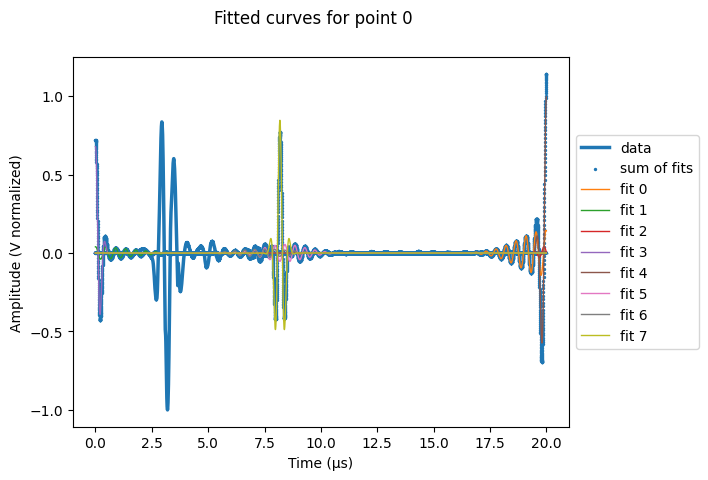

In [58]:
plt.plot(dset.t, dset[i][1], label='data', linewidth=2.5)
plt.scatter(dset.t, fits[i].sum(axis=0), s=2, label='sum of fits')  

for ind,f in enumerate(fits[i]):
    plt.plot(dset.t, fits[i][ind],  linewidth=1, label=f'fit {ind}')
     

plt.suptitle(f'Fitted curves for point {i}')
plt.xlabel('Time (μs)')
plt.ylabel('Amplitude (V normalized)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

# Model 2: morlet fit in fourier domain

## Dataloader with preprocessing

In [35]:
from data import datasets
from data.datasets import morlet_1D_fft_dataset

dset = morlet_1D_fft_dataset(sq3lite_path='/Users/xz498/Desktop/ultrasound/data_analysis/example_data/SA_tomography_test_metal_plate.sqlite3',
                              dset_name='voltage_echo_forward',
                              image_shape = (1,1),
                              lowpass = 200 # in index values. convert to MHz later
                            ) 

sqliteToPickle Warning: pickle file /Users/xz498/Desktop/ultrasound/data_analysis/example_data/SA_tomography_test_metal_plate.pickle already exists. Conversion aborted.
preprocessing data...


100%|██████████| 1/1 [00:00<00:00, 547.63it/s]


(1, 200)


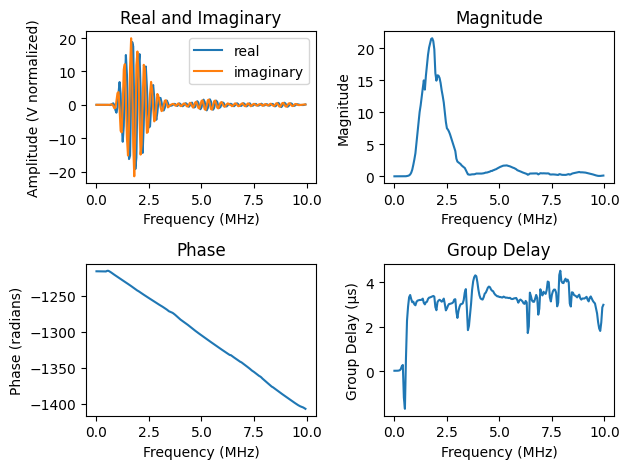

In [30]:
print(dset.shape)
fig, ax = plt.subplots(2,2)
ax = ax.flatten()

dat = dset[0][1]

ax[0].plot(dset.freq, np.real(dat), label='real',)
ax[0].plot(dset.freq, np.imag(dat), label='imaginary',)
ax[0].set_title('Real and Imaginary')
ax[0].set_ylabel('Amplitude (V normalized)')
ax[0].legend()

ax[1].plot(dset.freq, dset.magnitude_spectrum(0), label='magnitude')
ax[1].set_title('Magnitude')
ax[1].set_ylabel('Magnitude')

ax[2].plot(dset.freq, dset.phase_spectrum(0), label='phase')
ax[2].set_title('Phase')
ax[2].set_ylabel('Phase (radians)')

ax[3].plot(dset.freq, dset.group_delay(0), label='group delay')
ax[3].set_title('Group Delay')
ax[3].set_ylabel('Group Delay (μs)')

for a in ax: a.set_xlabel('Frequency (MHz)')

fig.tight_layout()

## try training model on water with morlet packet

goals:
- figure out mean position and f of morlet packet
- using this, calculate speed of sound in this water

In [41]:
from models.morlet_fitter_frequency import Fitter_AE, morlet_1D_complex_fitter
from autophyslearn.spectroscopic.nn import block_factory, Conv_Block, FC_Block 
from autophyslearn.spectroscopic.nn import Multiscale1DFitter

num_fits = 8 # number of curves to sum up
num_params = 4 # number of parameters to fit
# todo: change wandb naming to include noise level, group and regularization technique
# todo: test more num fits
model = Fitter_AE(function=morlet_1D_complex_fitter,
                dset=dset,
                num_params=num_params,
                num_fits=num_fits,
                checkpoints_label='ultrasound_metal_plate',
                input_channels = 1,
                learning_rate=3e-5,
                device='cpu',
                encoder = Multiscale1DFitter,
                encoder_params = {
                    "model_block_dict": { # factory wrapper for blocks
                            "hidden_x1": block_factory(Conv_Block)(output_channels_list=[128,128], 
                                                                    kernel_size_list=[5,5], 
                                                                    pool_list=[2000,500], 
                                                                    max_pool=False),
                            # "hidden_xfc": block_factory(FC_Block)(output_size_list=[128,64]), # remove 2nd block and skip connections
                            # "hidden_x2": block_factory(Conv_Block)(output_channels_list=[32,16], 
                            #                                         kernel_size_list=[75,75], 
                            #                                         pool_list=[64,32], 
                            #                                         max_pool=True),
                            "hidden_embedding": block_factory(FC_Block)(output_size_list=[8*num_fits,num_params*num_fits], last=True),
                        },
                        # TEST: LIMITS,
                        # "skip_connections": {'hidden_xfc': 'hidden_embedding'},
                        "skip_connections": {},
                        "function_kwargs": {'limits': [1, # amplitude
                                                       dset.spec_len, # mean
                                                       dset.spec_len/10, # stdev
                                                       1e-3] # freq max (100 MHz)
                                            } 
                    },
                )


### Train model for several epochs


In [44]:
# import wandb
# wandb.init(group='sub_sampler_type', name='sub_noise_level') # later change config for regularization

model.train(epochs=10,save_every=10, batch_size=1, log_wandb=False, 
            # lr_scheduling=True,
            # coef1=1e-3
            )

/Users/xz498/Desktop/ultrasound/data_analysis/example_data/ultrasound_metal_plate/checkpoints/voltage_echo_forward


100%|██████████| 1/1 [00:00<00:00,  8.43it/s]

Epoch: 000/010 | Train Loss: 35.7044
.............................



100%|██████████| 1/1 [00:00<00:00, 53.11it/s]


Epoch: 001/010 | Train Loss: 35.7044
.............................


...

Epoch: 007/010 | Train Loss: 35.7044
.............................


100%|██████████| 1/1 [00:00<00:00, 46.57it/s]


Epoch: 008/010 | Train Loss: 35.7044
.............................


100%|██████████| 1/1 [00:00<00:00, 52.76it/s]

Epoch: 009/010 | Train Loss: 35.7044
.............................


## Results

In [46]:
len(fits)

NameError: name 'fits' is not defined

In [53]:
import torch
def write_scaled_embedding(batch_size=1):
    for i, (idx, x) in enumerate(tqdm(model.dataloader, leave=True, total=len(model.dataloader))):
        with torch.no_grad():
            (fits, params_t), params_f = model.encoder(x.float().to(model.device))
            fits = fits.cpu().numpy()
            params = params_t.cpu().numpy()
    return fits, params, params_f.cpu().numpy()

fits, params, params_f = write_scaled_embedding(batch_size=1)

# sweep frequencies and search for resonances 
# attenuation in each layer accounts for spherical nature of wave
# data for one to 20 layers
# measure waveform from 30-50, measuring thermal gradient. shoul dbe the same as 40 (mean), so why isnt it?
# goal: use ultrasound to monitor the thermal expansion so we can decreasing charging rate. this way the battery is less likely to experience stress and can cycle more

100%|██████████| 1/1 [00:00<00:00, 211.78it/s]


In [55]:
import pandas as pd
i = 0 # which point are you looking at
params_df = pd.DataFrame(params[i], columns=['a_t','μ_t','σ_t','ω_t'])
params_df

,a_t,μ_t,σ_t,ω_t
0,0.083793,1.279291e+06,2.718148,4499.470703
1,0.099086,5.907218e+05,2.054842,4500.587891
2,0.246411,1.510769e+06,1.217037,4499.284180
3,0.084237,1.208753e+06,2.103988,4498.713379
4,0.201040,1.331798e+06,1.515110,4498.992188
5,0.138487,9.907184e+05,1.618813,4498.561523
6,0.102023,7.499001e+05,1.027636,4501.755859
7,0.156464,1.574548e+06,1.412834,4499.921387


/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/xz498/Applications/anaconda3/envs/ultrasound/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


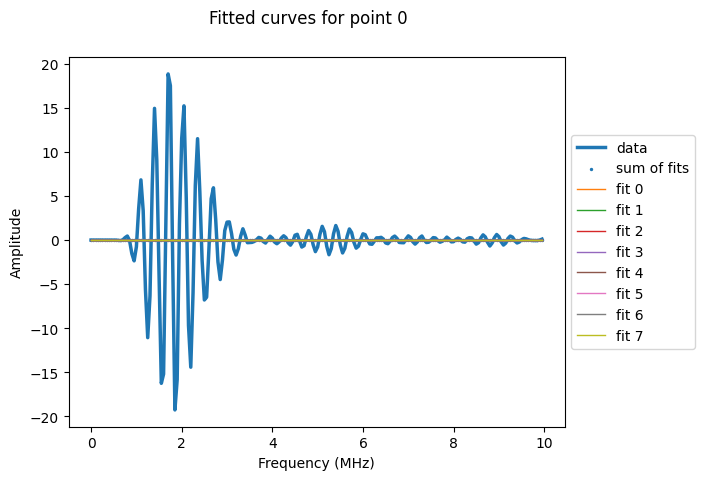

In [56]:
plt.plot(dset.freq, dset[i][1], label='data', linewidth=2.5)
plt.scatter(dset.freq, fits[i].sum(axis=0), s=2, label='sum of fits')  

for ind,f in enumerate(fits[i]):
    plt.plot(dset.freq, fits[i][ind],  linewidth=1, label=f'fit {ind}')
     

plt.suptitle(f'Fitted curves for point {i}')
plt.xlabel('Frequency (MHz)')
plt.ylabel('Amplitude')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)) 

# Model 3: Transfer Matrix

In [82]:
import numpy as np
import torch
sys.path.append('/Users/xz498/Desktop/ultrasound/data_analysis/tmm_fast/')
from tmm_fast import coh_tmm as tmm

wl = np.linspace(400, 1200, 800) * (10**(-9))
theta = np.linspace(0, 45, 45) * (np.pi/180)
mode = 'T'
num_layers = 4
num_stacks = 128

#create m
M = np.ones((num_stacks, num_layers, wl.shape[0]))
for i in range(1, M.shape[1]-1):
    if np.mod(i, 2) == 1:
        M[:, i, :] *= 1.46
    else:
        M[:, i, :] *= 2.56

#create t
max_t = 150 * (10**(-9))
min_t = 10 * (10**(-9))
T = (max_t - min_t) * np.random.uniform(0, 1, (M.shape[0], M.shape[1])) + min_t
T[:, 0] = np.inf
T[:, -1] = np.inf

#tmm:
O = tmm('s', M, T, theta, wl, device='cpu')

print(':)')

:)


In [89]:
M[0,1:-1,0],T[0,1:-1]

(array([1.46, 2.56]), array([3.6386800e-08, 8.7474917e-08]))

In [ ]:
M[:,1,0],T[0,:]

(<Axes: ylabel='Thickness in $\\mu$m'>,
 <matplotlib.colorizer._ScalarMappable at 0x31d060b00>)

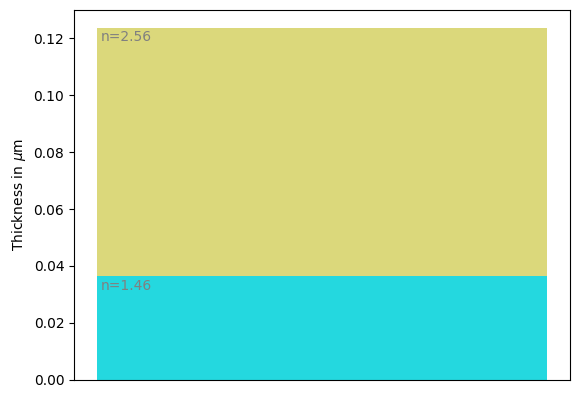

In [90]:
from tmm_fast import plot_stacks

fig, ax = plt.subplots()

plot_stacks(ax, M[0,1:-1,0],T[0,1:-1])

In [ ]:
from tmm_fast import plot_stacks

fig, ax = plt.subplots()

plot_stacks(ax, M[0,:,0], T[:,1])

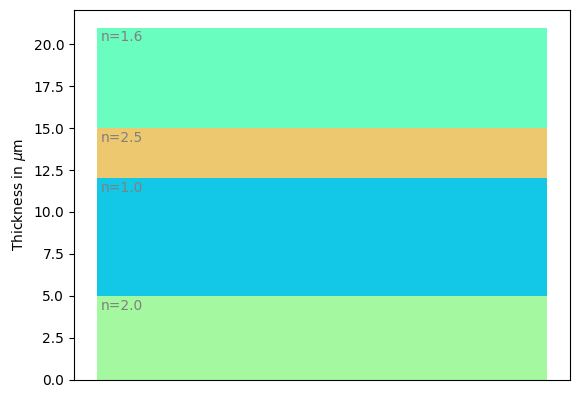

In [79]:
fig, ax = plt.subplots(1,1)
indexes = np.array([2, 1, 2.5, 1.6])
thickness = np.array([5, 7, 3, 6])*1e-6
labels = 'this is my stack'
ax, cmap = plot_stacks(ax, indexes, thickness, labels=labels ) 
plt.show()